In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train_path = r"C:\Users\divye\Data_science_projects\UXQuJpm6fj5xoNLi\data\ACME-HappinessSurvey2020.csv"

df = pd.read_csv(train_path)

df.head(20)

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5
5,1,5,5,3,5,5,5
6,0,3,1,2,2,1,3
7,1,5,4,4,4,4,5
8,0,4,1,4,4,4,4
9,0,4,4,4,2,5,5


In [14]:
df.isna().sum()

Y     0
X1    0
X2    0
X3    0
X4    0
X5    0
X6    0
dtype: int64

In [21]:
eda_df = df.copy()

label_map = {
    1: 'Very Unsatisfied',
    2: 'Unsatisfied',
    3: 'Neutral',
    4: 'Satisfied',
    5: 'Very Satisfied'
}
cols = ['X1', 'X2', 'X3', 'X4', 'X5','X6']
order = ['Very Unsatisfied','Unsatisfied','Neutral','Satisfied','Very Satisfied']

for col in cols:
    eda_df[f'{col}_label'] = pd.Categorical(
        eda_df[col].map(label_map),
        categories=order,
        ordered=True
    )

eda_df.head()

,Y,X1,X2,X3,X4,X5,X6,X1_label,X2_label,X3_label,X4_label,X5_label,X6_label
0,0,3,3,3,4,2,4,Neutral,Neutral,Neutral,Satisfied,Unsatisfied,Satisfied
1,0,3,2,3,5,4,3,Neutral,Unsatisfied,Neutral,Very Satisfied,Satisfied,Neutral
2,1,5,3,3,3,3,5,Very Satisfied,Neutral,Neutral,Neutral,Neutral,Very Satisfied
3,0,5,4,3,3,3,5,Very Satisfied,Satisfied,Neutral,Neutral,Neutral,Very Satisfied
4,0,5,4,3,3,3,5,Very Satisfied,Satisfied,Neutral,Neutral,Neutral,Very Satisfied


### EDA for the Happy Customers

In [22]:
#================== Checking the Balance of the Target varibles ==================================

cols_label = ['X1_label', 'X2_label', 'X3_label', 'X4_label', 'X5_label','X6_label']

# ── Filter happy customers (Y = 1) ───────────────────────────────────────────
happy_df = eda_df[eda_df['Y'] == 1]

print(f"Total customers  : {len(eda_df)}")
print(f"Happy (Y=1)      : {len(happy_df)}  ({len(happy_df)/len(eda_df)*100:.1f}%)")
print(f"Unhappy (Y=0)    : {len(eda_df) - len(happy_df)}  ({(len(eda_df)-len(happy_df))/len(eda_df)*100:.1f}%)")

Total customers  : 126
Happy (Y=1)      : 69  (54.8%)
Unhappy (Y=0)    : 57  (45.2%)


In [23]:
# ── Block 3 Fixed — % Satisfied & Very Satisfied for Y=1 vs Y=0 ──────────────
positive = ['Satisfied', 'Very Satisfied']       # happy responses
negative = ['Unsatisfied', 'Very Unsatisfied']   # unhappy responses

summary = pd.DataFrame()

for col in cols_label:
    for y_val, group_name in [(1, 'Happy (Y=1)'), (0, 'Unhappy (Y=0)')]:
        group = eda_df[eda_df['Y'] == y_val]
        total = len(group)
        summary.loc[col, f'{group_name} | % Satisfied+']   = round(group[col].isin(positive).sum() / total * 100, 1)
        summary.loc[col, f'{group_name} | % Neutral']      = round((group[col] == 'Neutral').sum() / total * 100, 1)
        summary.loc[col, f'{group_name} | % Unsatisfied-'] = round(group[col].isin(negative).sum() / total * 100, 1)

print(summary)

          Happy (Y=1) | % Satisfied+  Happy (Y=1) | % Neutral  \
X1_label                        88.4                     11.6   
X2_label                        15.9                     33.3   
X3_label                        47.8                     37.7   
X4_label                        65.2                     30.4   
X5_label                        72.5                     14.5   
X6_label                        89.9                      8.7   

          Happy (Y=1) | % Unsatisfied-  Unhappy (Y=0) | % Satisfied+  \
X1_label                           0.0                          77.2   
X2_label                          50.7                          21.1   
X3_label                          14.5                          29.8   
X4_label                           4.3                          57.9   
X5_label                          13.0                          54.4   
X6_label                           1.4                          73.7   

          Unhappy (Y=0) | % Neutral  Un

In [24]:
from scipy.stats import pointbiserialr, chi2_contingency
import numpy as np

# ── 1. Point-Biserial Correlation — each X col (numeric) vs Y ────────────────
print("── Correlation with Y (numeric cols) ──\n")
for col in cols:
    r, p = pointbiserialr(df['Y'], df[col])
    signal = '✓ Signal' if p < 0.05 else '✗ Noise'
    print(f"{col}:  r = {r:+.3f},  p = {p:.4f}  →  {signal}")

── Correlation with Y (numeric cols) ──

X1:  r = +0.280,  p = 0.0015  →  ✓ Signal
X2:  r = -0.024,  p = 0.7873  →  ✗ Noise
X3:  r = +0.151,  p = 0.0918  →  ✗ Noise
X4:  r = +0.064,  p = 0.4736  →  ✗ Noise
X5:  r = +0.225,  p = 0.0115  →  ✓ Signal
X6:  r = +0.168,  p = 0.0606  →  ✗ Noise


In [25]:
# ── 2. Chi-Square Test — each label col vs Y (categorical) ───────────────────
print("\n── Chi-Square Test (label cols vs Y) ──\n")
for col in cols_label:
    ct = pd.crosstab(eda_df[col], df['Y'])
    chi2, p, dof, _ = chi2_contingency(ct)
    signal = '✓ Signal' if p < 0.05 else '✗ Noise'
    print(f"{col}:  chi2 = {chi2:.3f},  p = {p:.4f}  →  {signal}")


── Chi-Square Test (label cols vs Y) ──

X1_label:  chi2 = 11.981,  p = 0.0074  →  ✓ Signal
X2_label:  chi2 = 2.375,  p = 0.6671  →  ✗ Noise
X3_label:  chi2 = 4.340,  p = 0.3619  →  ✗ Noise
X4_label:  chi2 = 4.648,  p = 0.3253  →  ✗ Noise
X5_label:  chi2 = 6.808,  p = 0.1464  →  ✗ Noise
X6_label:  chi2 = 8.138,  p = 0.0866  →  ✗ Noise


In [27]:
# ── Consolidated Signal Table — all 3 methods side by side ───────────────────
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cols_num   = ['X1', 'X2', 'X3', 'X4', 'X5','X6']   # update if X6 exists
cols_label = ['X1_label', 'X2_label', 'X3_label', 'X4_label', 'X5_label','X6_label']

results = pd.DataFrame(index=cols_num)

# -- Point-Biserial Correlation
for col in cols_num:
    r, p = pointbiserialr(eda_df['Y'], eda_df[col])
    results.loc[col, 'Correlation (r)'] = round(r, 3)
    results.loc[col, 'Corr p-value']    = round(p, 4)
    results.loc[col, 'Corr Signal']     = 'Yes' if p < 0.05 else 'No'

# -- Chi-Square
for col, col_label in zip(cols_num, cols_label):
    ct = pd.crosstab(eda_df[col_label], eda_df['Y'])
    chi2, p, _, _ = chi2_contingency(ct)
    results.loc[col, 'Chi2 p-value'] = round(p, 4)
    results.loc[col, 'Chi2 Signal']  = 'Yes' if p < 0.05 else 'No'

# -- Random Forest Importance
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(eda_df[cols_num], eda_df['Y'])
for col, imp in zip(cols_num, rf.feature_importances_):
    results.loc[col, 'RF Importance'] = round(imp, 4)

# -- Count how many methods flagged it as signal
results['RF Signal'] = results['RF Importance'] > results['RF Importance'].mean()
results['Votes']     = (
    (results['Corr Signal'] == 'Yes').astype(int) +
    (results['Chi2 Signal'] == 'Yes').astype(int) +
    results['RF Signal'].astype(int)
)
results = results.sort_values('Votes', ascending=False)
print(results)

    Correlation (r)  Corr p-value Corr Signal  Chi2 p-value Chi2 Signal  \
X1            0.280        0.0015         Yes        0.0074         Yes   
X5            0.225        0.0115         Yes        0.1464          No   
X2           -0.024        0.7873          No        0.6671          No   
X3            0.151        0.0918          No        0.3619          No   
X4            0.064        0.4736          No        0.3253          No   
X6            0.168        0.0606          No        0.0866          No   

    RF Importance  RF Signal  Votes  
X1         0.1711       True      3  
X5         0.1817       True      2  
X2         0.1795       True      1  
X3         0.1904       True      1  
X4         0.1478      False      0  
X6         0.1296      False      0  


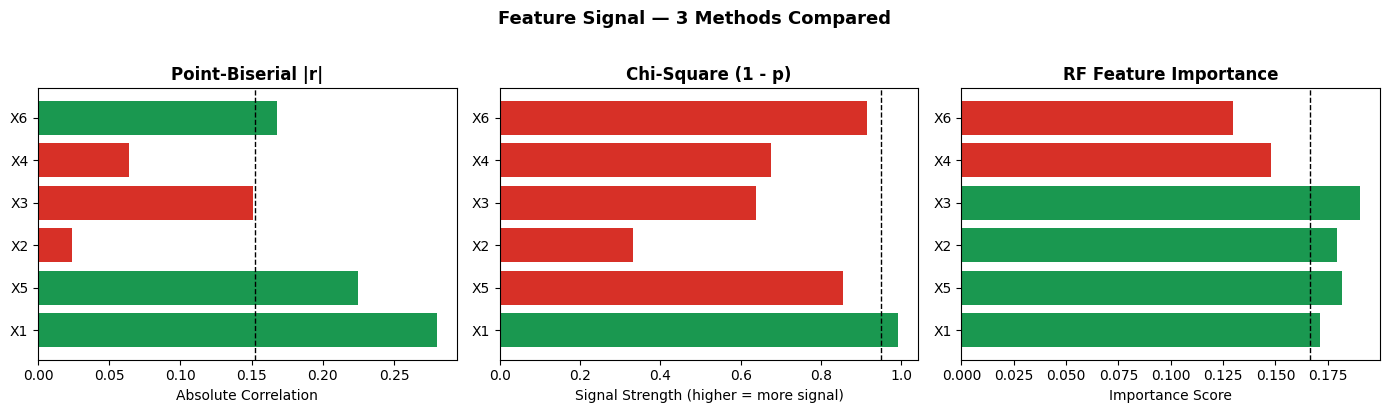

In [28]:
# ── Visual: Heatmap of all 3 methods ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Correlation
corr_vals = results['Correlation (r)'].abs()
axes[0].barh(results.index, corr_vals,
             color=['#1a9850' if v > corr_vals.mean() else '#d73027' for v in corr_vals])
axes[0].axvline(corr_vals.mean(), color='black', linestyle='--', linewidth=1)
axes[0].set_title('Point-Biserial |r|', fontweight='bold')
axes[0].set_xlabel('Absolute Correlation')

# Chi-Square p-value (inverted — lower p = more signal)
chi_vals = 1 - results['Chi2 p-value']
axes[1].barh(results.index, chi_vals,
             color=['#1a9850' if p < 0.05 else '#d73027' for p in results['Chi2 p-value']])
axes[1].axvline(0.95, color='black', linestyle='--', linewidth=1, label='p=0.05 threshold')
axes[1].set_title('Chi-Square (1 - p)', fontweight='bold')
axes[1].set_xlabel('Signal Strength (higher = more signal)')

# RF Importance
rf_vals = results['RF Importance']
axes[2].barh(results.index, rf_vals,
             color=['#1a9850' if v > rf_vals.mean() else '#d73027' for v in rf_vals])
axes[2].axvline(rf_vals.mean(), color='black', linestyle='--', linewidth=1)
axes[2].set_title('RF Feature Importance', fontweight='bold')
axes[2].set_xlabel('Importance Score')

plt.suptitle('Feature Signal — 3 Methods Compared', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Out of the five features analysed, X4 — "I paid a good price for my order" and X6 — "The app makes ordering easy for me" showed the least influence on the target variable Y (Happy/Unhappy customer). Both were dropped from the final model as they contributed minimal predictive signal compared to the remaining features.

This suggests that pricing perception and app usability are not the primary drivers of customer happiness or unhappiness in this dataset. Customers tend to form their overall satisfaction based more on other aspects of their experience rather than price or ease of ordering.

In [44]:
model_df = df.copy()

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import pandas as pd
import numpy as np

# ── Features & Target ─────────────────────────────────────────────────────────
feature_cols = ['X1', 'X2', 'X3', 'X5']

model_df['avg_score']         = model_df[feature_cols].mean(axis=1)
model_df['satisfied_count']   = (model_df[feature_cols] >= 4).sum(axis=1)
model_df['unsatisfied_count'] = (model_df[feature_cols] <= 2).sum(axis=1)
model_df['score_std']         = model_df[feature_cols].std(axis=1)

all_features = feature_cols + ['avg_score', 'satisfied_count', 'unsatisfied_count', 'score_std']

X = model_df[all_features]
y = model_df['Y']

# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total rows  : {len(X)}")
print(f"Train rows  : {len(X_train)}")
print(f"Test rows   : {len(X_test)}")
print(f"Class split : {y.value_counts().to_dict()}")

Total rows  : 126
Train rows  : 100
Test rows   : 26
Class split : {1: 69, 0: 57}


In [69]:
# ── Models ────────────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(C=0.1, max_iter=1000, random_state=42))
    ]),
    'SVM': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  SVC(kernel='rbf', C=1, probability=True, random_state=42))
    ]),
    'Random Forest': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('model',  RandomForestClassifier(n_estimators=100, max_depth=4, random_state=42))
    ]),
    'Gradient Boosting': ImbPipeline([
        ('smote',  SMOTE(random_state=42)),
        ('model',  GradientBoostingClassifier(n_estimators=100, max_depth=3,
                                              learning_rate=0.05, random_state=42))
    ]),
}

# ── Train, Test & CV Evaluate ─────────────────────────────────────────────────
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
results = {}

for name, pipeline in models.items():
    # Train on train set
    pipeline.fit(X_train, y_train)

    # Test set scores
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    test_acc = accuracy_score(y_test, y_pred) * 100
    test_auc = roc_auc_score(y_test, y_prob)

    # CV on full training set only
    cv_auc = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_acc = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    results[name] = {
        'Test Accuracy %' : round(test_acc, 2),
        'Test ROC-AUC'    : round(test_auc, 4),
        'CV Accuracy %'   : round(cv_acc.mean() * 100, 2),
        'CV AUC Mean'     : round(cv_auc.mean(), 4),
        'CV AUC Std'      : round(cv_auc.std(), 4),
    }

results_df = pd.DataFrame(results).T.sort_values('Test Accuracy %', ascending=False)
print(results_df)

                     Test Accuracy %  Test ROC-AUC  CV Accuracy %  \
SVM                            69.23        0.6875           49.6   
Random Forest                  69.23        0.7411           57.2   
Logistic Regression            61.54        0.7530           53.7   
Gradient Boosting              57.69        0.6577           59.2   

                     CV AUC Mean  CV AUC Std  
SVM                       0.5054      0.1058  
Random Forest             0.5959      0.1204  
Logistic Regression       0.5714      0.1216  
Gradient Boosting         0.6057      0.1154  


The model Random Forest and SVM are giving more Test accuracy However, SVM model is very unstable where the Cross Validation of the 5-Folds Accuracy% is very less compare to others which takes out the SVM Model. 

The Random Forest is good in single test Accuracy%. But the Model is liekly to be overfitting because of the 5-Fold Cross validation is 57.2% which has more gap with 69.23% 

The Gradient Boosting is very stable but having a less Accuracy score where The single fold Accuracy 57.69 while with the 5-Fold its only varies about 59.2% which is having a less gap.
